# Prepare data

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
from IPython.display import display

In [2]:
# read the new dataframe
crime_count_df = pd.read_csv("crime_count_df.csv")
crime_count_df['crime date'] = pd.to_datetime(crime_count_df['crime date'])  # convert to datetime
crime_count_df.set_index('crime date', inplace=True)           # make date the index
crime_count_df = crime_count_df.asfreq('D')                              # ensure daily frequency

# Check for missing dates (NaNs may appear if any days are missing)
crime_count_df = crime_count_df.fillna(0)
warnings.filterwarnings('ignore')

<Axes: xlabel='crime date'>

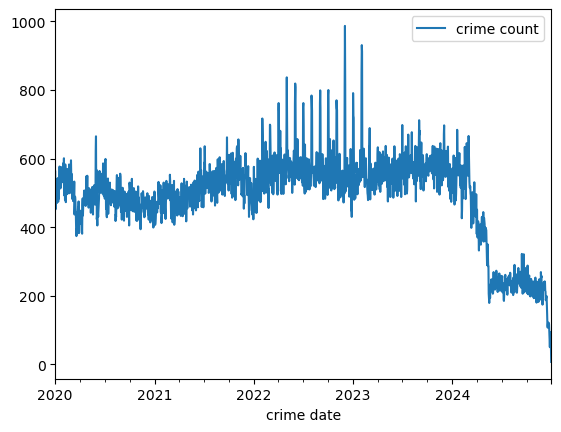

In [3]:
crime_count_df.plot()

<Axes: xlabel='crime date'>

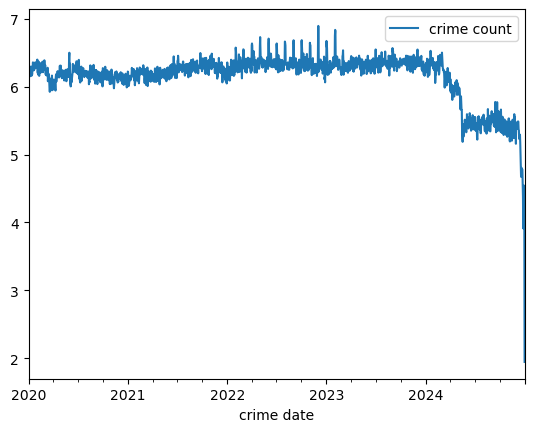

In [4]:
copy = np.log(crime_count_df)
copy.plot()

## Split Dataset

In [5]:
crime_count_df = crime_count_df.reset_index()

# the train dataset is from the beginning of January 2020 until the beginning of October 2024
train = crime_count_df[crime_count_df['crime date'] < '2024-10-01']
test = crime_count_df[crime_count_df['crime date'] >= '2024-10-01']


In [6]:
train.set_index('crime date', inplace=True)
test.set_index('crime date', inplace=True)

## ACF and PACF plot

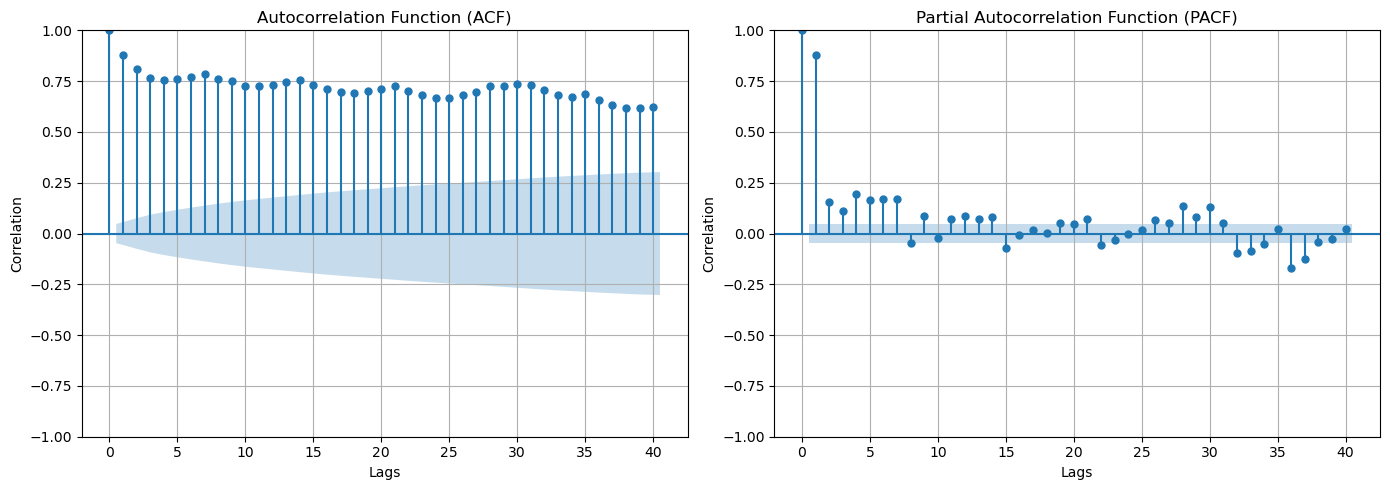

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ACF
plot_acf(train, lags=40, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Correlation")
axes[0].grid(True)

# PACF
plot_pacf(train, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF)")
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Correlation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Transform to stationary

<Axes: xlabel='crime date'>

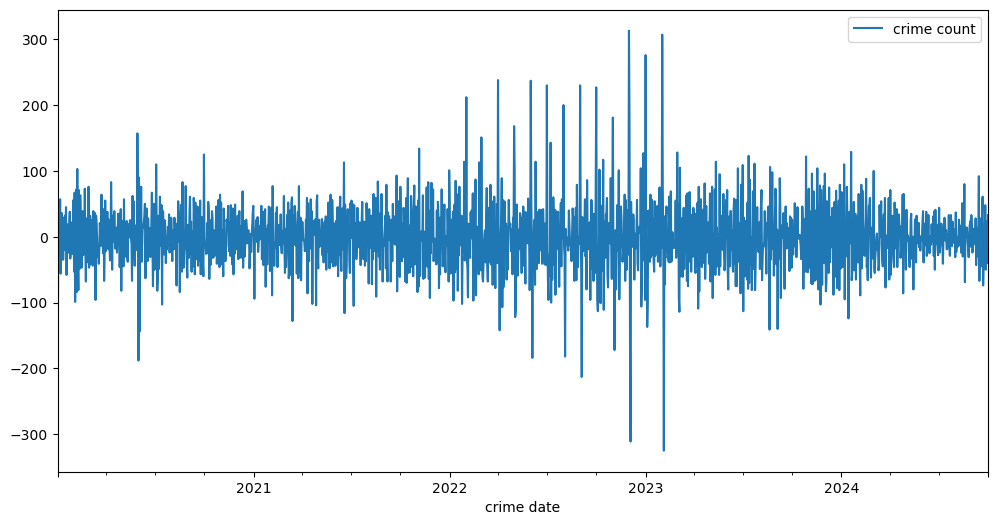

In [8]:
train_diff = train.diff().dropna()
train_diff.plot(figsize=(12, 6))

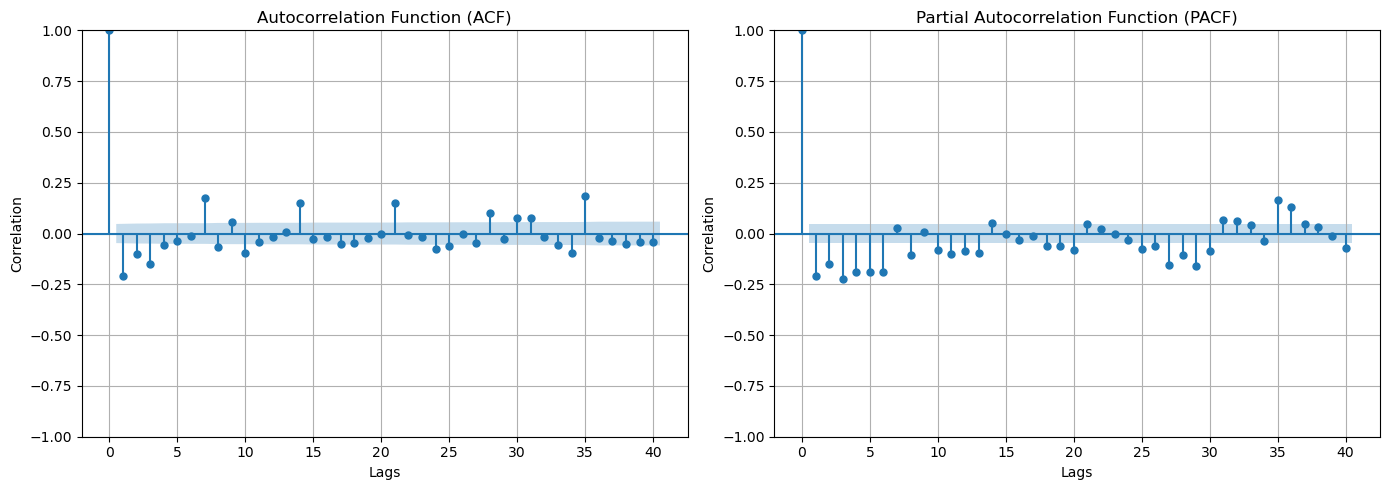

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ACF
plot_acf(train_diff, lags=40, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Correlation")
axes[0].grid(True)

# PACF
plot_pacf(train_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF)")
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Correlation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## AIC Function

In [10]:
# here is for SARIMA:
import statsmodels.api as sm
import itertools
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Define the p, d, q parameters to take values between 0 and 2
p = d = q = range(0, 3)  # you can expand this if needed
pdq = list(itertools.product(p, d, q))

# Define the seasonal p, d, q parameters
seasonal_pdq = [(x[0], x[1], x[2], 7) for x in pdq]  # here s=7 (weekly seasonality)

results = []

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            model_sarima = sm.tsa.statespace.SARIMAX(train,
                                                     order=param,
                                                     seasonal_order=seasonal_param,
                                                     enforce_stationarity=False,
                                                     enforce_invertibility=False)
            model_fit = model_sarima.fit(disp=False)
            aic_value = model_fit.aic
            results.append((param, seasonal_param, aic_value))
            print(f"ARIMA{param}xSARIMA{seasonal_param} - AIC:{aic_value}")
        except:
            continue

# Sort results by lowest AIC
results = sorted(results, key=lambda x: x[2])
print("\nBest SARIMA parameters:", results[0])

ARIMA(0, 0, 0)xSARIMA(0, 0, 0, 7) - AIC:26583.1023337811
ARIMA(0, 0, 0)xSARIMA(0, 0, 1, 7) - AIC:24471.560674210185
ARIMA(0, 0, 0)xSARIMA(0, 0, 2, 7) - AIC:23045.619668248997
ARIMA(0, 0, 0)xSARIMA(0, 1, 0, 7) - AIC:19416.40471774731
ARIMA(0, 0, 0)xSARIMA(0, 1, 1, 7) - AIC:18696.07300440146
ARIMA(0, 0, 0)xSARIMA(0, 1, 2, 7) - AIC:18624.19714745759
ARIMA(0, 0, 0)xSARIMA(0, 2, 0, 7) - AIC:21174.881407814544
ARIMA(0, 0, 0)xSARIMA(0, 2, 1, 7) - AIC:19306.909085539446
ARIMA(0, 0, 0)xSARIMA(0, 2, 2, 7) - AIC:18584.25307868843
ARIMA(0, 0, 0)xSARIMA(1, 0, 0, 7) - AIC:19420.256782372846
ARIMA(0, 0, 0)xSARIMA(1, 0, 1, 7) - AIC:18764.8132971
ARIMA(0, 0, 0)xSARIMA(1, 0, 2, 7) - AIC:18692.315673101868
ARIMA(0, 0, 0)xSARIMA(1, 1, 0, 7) - AIC:18964.697076339096
ARIMA(0, 0, 0)xSARIMA(1, 1, 1, 7) - AIC:18697.784095687828
ARIMA(0, 0, 0)xSARIMA(1, 1, 2, 7) - AIC:18626.070029648803
ARIMA(0, 0, 0)xSARIMA(1, 2, 0, 7) - AIC:20158.610814757078
ARIMA(0, 0, 0)xSARIMA(1, 2, 1, 7) - AIC:18923.26570484895
ARIMA(0, 

# Model Planning/Building

## Model 1: (0, 1, 2), (0, 1, 2, 30)

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# ====== 1. Fit SARIMA ======
model = SARIMAX(train,
                order=(0, 1, 2),
                seasonal_order=(0, 1, 2, 30))
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        crime count   No. Observations:                 1735
Model:             SARIMAX(0, 1, 2)x(0, 1, 2, 30)   Log Likelihood               -8972.743
Date:                            Wed, 20 Aug 2025   AIC                          17955.487
Time:                                    14:09:54   BIC                          17982.690
Sample:                                01-01-2020   HQIC                         17965.556
                                     - 09-30-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5173      0.013    -38.443      0.000      -0.544      -0.491
ma.L2         -0.3277      0.016   

In [12]:
# ====== 2. Forecast ======
forecast_steps = len(test)
forecast_obj = results.get_forecast(steps=forecast_steps)
forecast_df = forecast_obj.conf_int()
forecast_df['Prediction'] = forecast_obj.predicted_mean
forecast_df.index = test.index  # align with actual test dates

In [13]:
# ====== 3. Evaluate ======
mae = mean_absolute_error(test, forecast_df['Prediction'])
rmse = np.sqrt(mean_squared_error(test, forecast_df['Prediction']))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 43.28, RMSE: 65.25


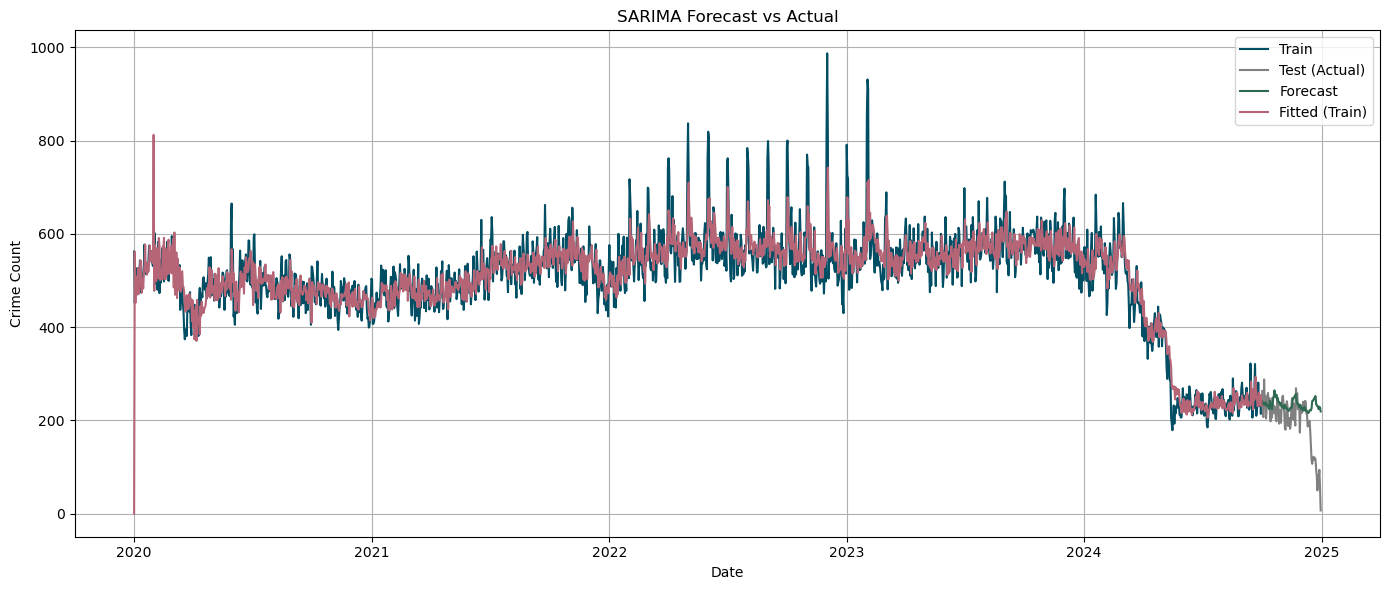

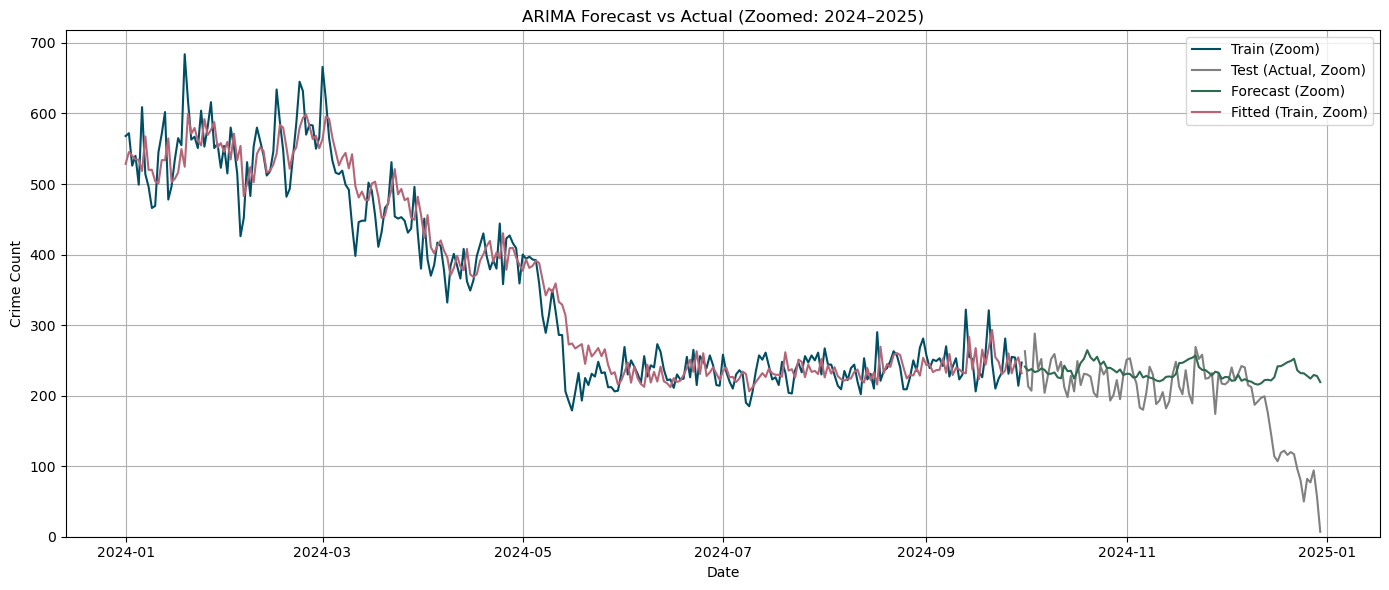

In [14]:
# ====== 4. Plot ======
plt.figure(figsize=(14, 6))

# Train and Test
plt.plot(train.index, train, label='Train', color='#004e64')
plt.plot(test.index, test, label='Test (Actual)', color='gray')

# Forecast
plt.plot(forecast_df.index, forecast_df['Prediction'], label='Forecast', color='#2d6a4f')

# Fitted values (train only)
plt.plot(train.index, results.fittedvalues, label='Fitted (Train)', color='#b56576')

# Styling
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

# Only keep values from 2024 onwards
zoom_start = '2024-01-01'
train_zoom = train[train.index >= zoom_start]
test_zoom = test[test.index >= zoom_start]
forecast_zoom = forecast_df[forecast_df.index >= zoom_start]

plt.plot(train_zoom.index, train_zoom, label='Train (Zoom)', color='#004e64')
plt.plot(test_zoom.index, test_zoom, label='Test (Actual, Zoom)', color='gray')
plt.plot(forecast_zoom.index, forecast_zoom['Prediction'], label='Forecast (Zoom)', color='#2d6a4f')
plt.plot(train_zoom.index, results.fittedvalues[train_zoom.index], label='Fitted (Train, Zoom)', color='#b56576')

plt.title('ARIMA Forecast vs Actual (Zoomed: 2024–2025)')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

## Model 2: (1, 1, 2), (0, 1, 2, 7)

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# ====== 1. Fit SARIMA ======
model = SARIMAX(train,
                order=(1, 1, 2),
                seasonal_order=(0, 1, 2, 7))
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       crime count   No. Observations:                 1735
Model:             SARIMAX(1, 1, 2)x(0, 1, 2, 7)   Log Likelihood               -8933.952
Date:                           Wed, 20 Aug 2025   AIC                          17879.903
Time:                                   14:10:02   BIC                          17912.628
Sample:                               01-01-2020   HQIC                         17892.008
                                    - 09-30-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4878      0.040     12.132      0.000       0.409       0.567
ma.L1         -0.9088      0.044    -20.509

In [16]:
# ====== 2. Forecast ======
forecast_steps = len(test)
forecast_obj = results.get_forecast(steps=forecast_steps)
forecast_df = forecast_obj.conf_int()
forecast_df['Prediction'] = forecast_obj.predicted_mean
forecast_df.index = test.index  # align with actual test dates

In [17]:
# ====== 3. Evaluate ======
mae = mean_absolute_error(test, forecast_df['Prediction'])
rmse = np.sqrt(mean_squared_error(test, forecast_df['Prediction']))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 33.96, RMSE: 49.64


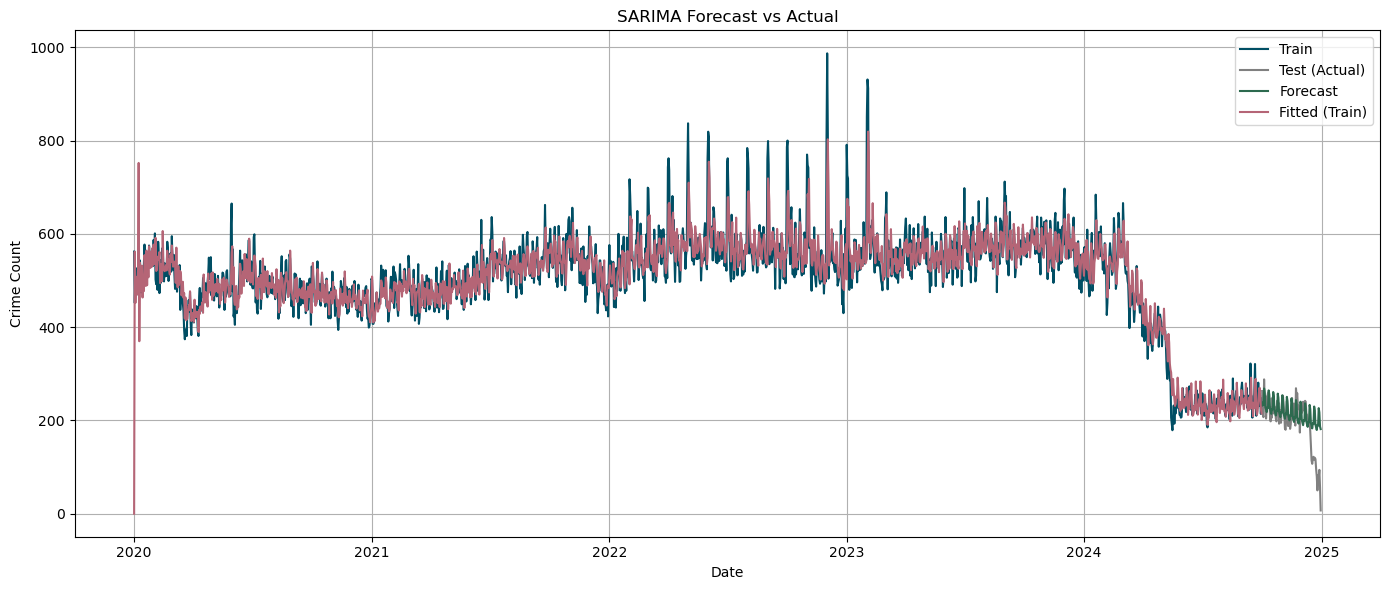

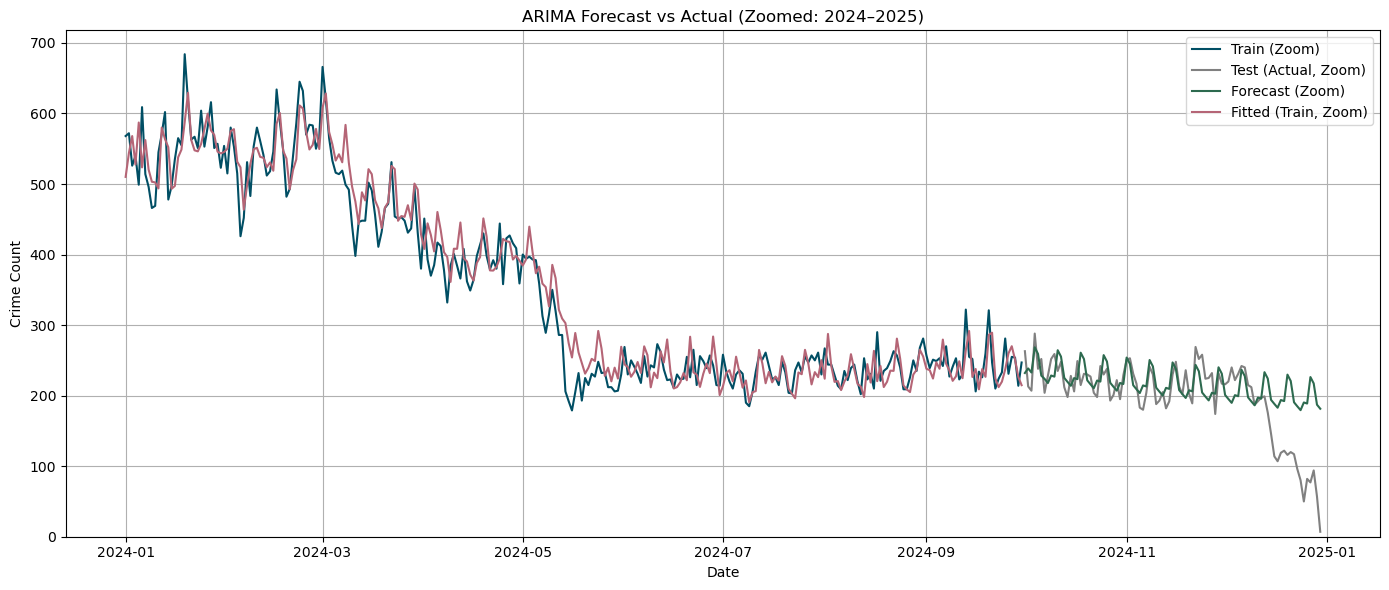

In [18]:
# ====== 4. Plot ======
plt.figure(figsize=(14, 6))

# Train and Test
plt.plot(train.index, train, label='Train', color='#004e64')
plt.plot(test.index, test, label='Test (Actual)', color='gray')

# Forecast
plt.plot(forecast_df.index, forecast_df['Prediction'], label='Forecast', color='#2d6a4f')

# Fitted values (train only)
plt.plot(train.index, results.fittedvalues, label='Fitted (Train)', color='#b56576')

# Styling
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

# Only keep values from 2024 onwards
zoom_start = '2024-01-01'
train_zoom = train[train.index >= zoom_start]
test_zoom = test[test.index >= zoom_start]
forecast_zoom = forecast_df[forecast_df.index >= zoom_start]

plt.plot(train_zoom.index, train_zoom, label='Train (Zoom)', color='#004e64')
plt.plot(test_zoom.index, test_zoom, label='Test (Actual, Zoom)', color='gray')
plt.plot(forecast_zoom.index, forecast_zoom['Prediction'], label='Forecast (Zoom)', color='#2d6a4f')
plt.plot(train_zoom.index, results.fittedvalues[train_zoom.index], label='Fitted (Train, Zoom)', color='#b56576')

plt.title('ARIMA Forecast vs Actual (Zoomed: 2024–2025)')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()